pyRing version: 2.8.1
KerrBH: FOUND
MMRDNS: FOUND
MMRDNP: FOUND

Constructor signatures

KerrBH
signature: <unavailable> ValueError("no signature found for builtin type <class 'pyRing.waveform.KerrBH'>")
doc preview:
    | Multi mode ringdown model for a Kerr black hole using predictions of the frequencies and damping times as function of mass and spin, as predicted by perturbation theory.
    |
    | [Input parameters]
    |
    | t0    : Start time of the analysis (s), and reference time of the amplitudes, currently common for all modes. #IMPROVEME: allow for a different start time for each mode.
    | Mf    : Final mass in solar masses.
    | af    : Dimensionless final spin.
    | amps  : Amplitudes of the (s,l,m,n) modes. Expected syntax: amps[(s,l,m,n)] = `value`. The keys of this dictionary set the modes used in the waveform.
    | r     : Distance in Mpc.
    | iota  : Inclination in radians.
    | phi   : Azimuthal angle in radians.
    |
    | [Optional parameters]
    |
    

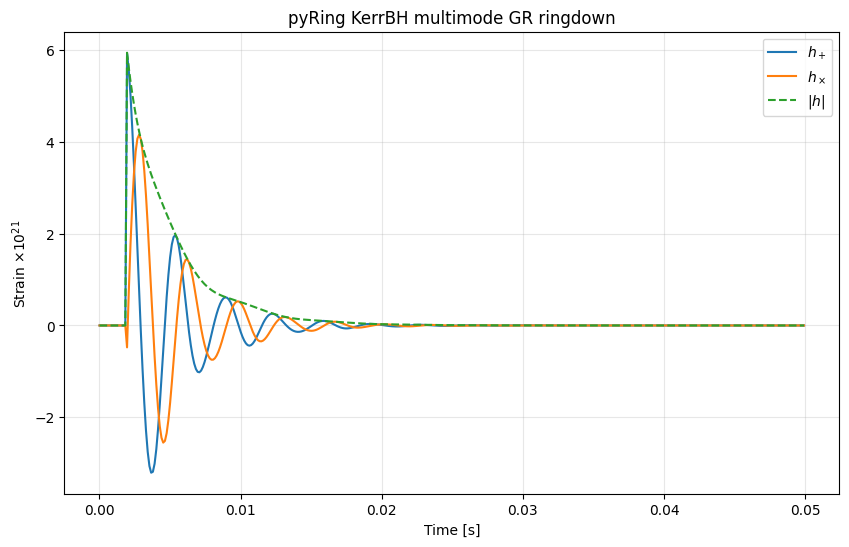

Type of raw_kerrbh_obj: <class 'numpy.ndarray'>
Shape of raw_kerrbh_obj: (5, 410)
dtype: float64
ndim: 2
channel 0: min=0.000e+00, max=0.000e+00
channel 1: min=0.000e+00, max=0.000e+00
channel 2: min=0.000e+00, max=0.000e+00
channel 3: min=-3.207e-21, max=5.922e-21
channel 4: min=-2.551e-21, max=4.156e-21


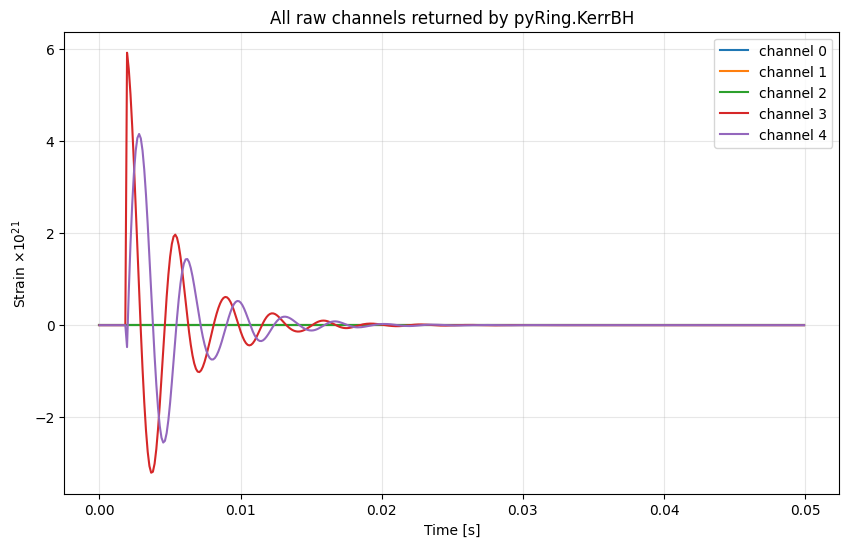


MMRDNS multimode
----------------
t shape: (410,)
h_plus shape: (410,)
h_cross shape: (410,)
max |h|: 1.0132633734934912e-21
max |h_plus|: 9.390094811493596e-22
max |h_cross|: 7.563878566871157e-22

MMRDNS raw output type: <class 'numpy.ndarray'>
MMRDNS raw output shape: (5, 410)


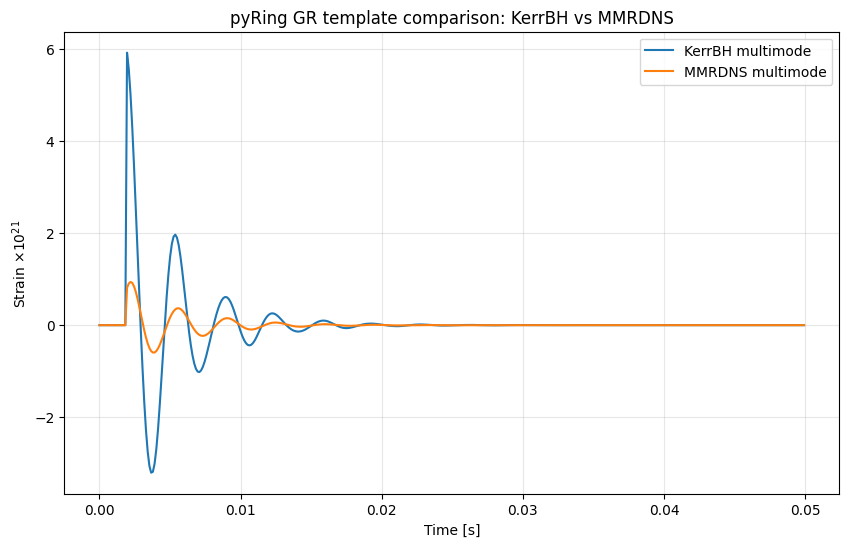

Time-domain comparison
Overlap(KerrBH, MMRDNS multimode)  = 0.950631
Mismatch(KerrBH, MMRDNS multimode) = 0.049369


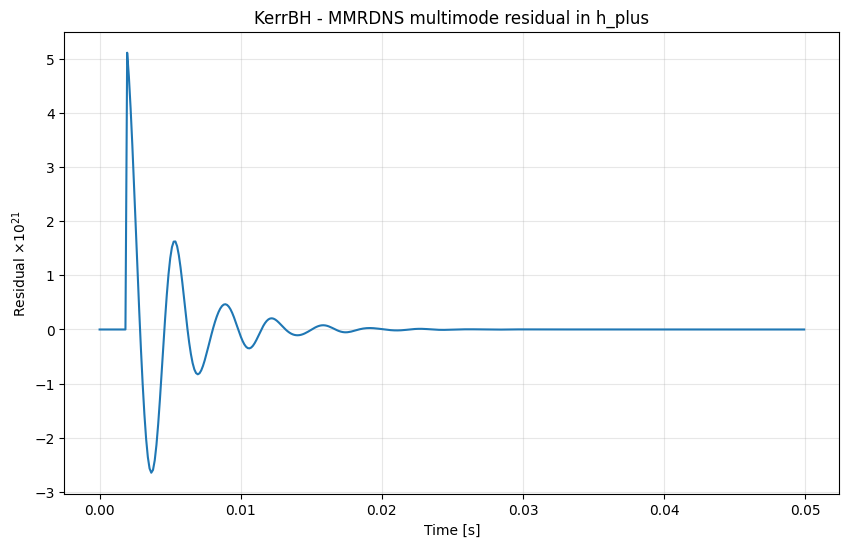

{'duration_s': 0.05,
 'sample_rate_hz': 8192,
 'n_samples': 410,
 'baseline_model': 'KerrBH',
 'comparison_model': 'MMRDNS_multimode',
 'time_domain_overlap': 0.9506312090442038,
 'time_domain_mismatch': 0.04936879095579616}

In [4]:
# ============================================================
# NOTEBOOK 05

# What this block does:
# 1. Installs pyRingGW into the active Jupyter kernel if needed
# 2. Imports pyRing and the waveform submodule
# 3. Prints version / class availability
# 4. Prints constructor signatures and short doc previews


import inspect
import textwrap
import numpy as np
import matplotlib.pyplot as plt

import pyRing
from pyRing import waveform as pyr_wf
from pyRing import inject_signal as pyr_inj


print("pyRing version:", getattr(pyRing, "__version__", "version not exposed"))

# Print the main classes we care about
candidate_names = ["KerrBH", "MMRDNS", "MMRDNP"]
for name in candidate_names:
    obj = getattr(pyr_wf, name, None)
    print(f"{name}: {'FOUND' if obj is not None else 'MISSING'}")

print("\n" + "=" * 80)
print("Constructor signatures")
print("=" * 80)

for name in candidate_names:
    obj = getattr(pyr_wf, name, None)
    if obj is None:
        continue

    print(f"\n{name}")
    try:
        print("signature:", inspect.signature(obj))
    except Exception as e:
        print("signature: <unavailable>", repr(e))

    doc = inspect.getdoc(obj)
    if doc:
        preview = "\n".join(doc.splitlines()[:20])
        print("doc preview:")
        print(textwrap.indent(preview, prefix="    "))
    else:
        print("doc preview: <no docstring available>")

print("\n" + "=" * 80)
print("High-level injection helpers")
print("=" * 80)

for fn_name in ["inject_ringdown_signal", "kerr_injection", "mmrdns_injection", "mmrdnp_injection"]:
    fn = getattr(pyr_inj, fn_name, None)
    print(f"{fn_name}: {'FOUND' if fn is not None else 'MISSING'}")
    if fn is not None:
        try:
            print("  signature:", inspect.signature(fn))
        except Exception as e:
            print("  signature: <unavailable>", repr(e))

# ============================================================
# BLOCK 3A (CORRECTED UNPACKING VERSION)
#
# What this block fixes:
# - pyRing returned a 2D ndarray of shape (5, N)
# - for this case, we interpret:
#     raw[0] = hs
#     raw[1] = hvx
#     raw[2] = hvy
#     raw[3] = h_plus
#     raw[4] = h_cross
#
# This matches the pyRing documentation for five-polarization outputs.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

duration = 0.05
fs = 8192
dt = 1.0 / fs
times = np.arange(0.0, duration, dt)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def unpack_waveform_output(raw):
    """
    Convert a pyRing waveform return value into h_plus, h_cross, raw.

    Cases handled:
    1. 1D complex ndarray:
       interpret as h_plus - i h_cross

    2. 2D ndarray with shape (5, N):
       interpret as [hs, hvx, hvy, h_plus, h_cross]

    3. tuple/list length 2:
       interpret as (h_plus, h_cross)

    4. tuple/list length 5:
       interpret as (hs, hvx, hvy, h_plus, h_cross)
    """
    if isinstance(raw, np.ndarray):
        # Case 1: 1D complex array
        if raw.ndim == 1:
            if np.iscomplexobj(raw):
                hp = np.real(raw)
                hc = -np.imag(raw)
                return hp, hc, raw
            else:
                hp = np.asarray(raw, dtype=float)
                hc = np.zeros_like(hp)
                return hp, hc, raw

        # Case 2: 2D array with five polarization channels
        if raw.ndim == 2 and raw.shape[0] == 5:
            hp = np.asarray(raw[3], dtype=float)
            hc = np.asarray(raw[4], dtype=float)
            return hp, hc, raw

    # Case 3/4: tuple/list returns
    if isinstance(raw, (tuple, list)):
        if len(raw) == 2:
            return np.asarray(raw[0]), np.asarray(raw[1]), raw
        if len(raw) == 5:
            return np.asarray(raw[3]), np.asarray(raw[4]), raw

    raise TypeError(f"Unsupported waveform return type: {type(raw)} with shape {getattr(raw, 'shape', None)}")


def summarize_template(name, t, hp, hc):
    h_complex = hp - 1j * hc
    env = np.abs(h_complex)

    print(f"\n{name}")
    print("-" * len(name))
    print("t shape:", t.shape)
    print("h_plus shape:", hp.shape)
    print("h_cross shape:", hc.shape)
    print("max |h|:", np.max(env))
    print("max |h_plus|:", np.max(np.abs(hp)))
    print("max |h_cross|:", np.max(np.abs(hc)))


# Use s=2 keys for KerrBH tensor gravitational modes in pyRing
# and give each mode (amplitude, phase)
amps_dict = {
    (2, 2, 2, 0): (1.00, 0.00),
    (2, 2, 2, 1): (0.45, 0.30),
    (2, 3, 3, 0): (0.25, -0.50),
}

kerrbh_model = pyr_wf.KerrBH(
    t0=0.002,
    Mf=60.0,
    af=0.7,
    amps=amps_dict,
    r=400.0,
    iota=0.3,
    phi=0.0,
    qnm_fit=1,
    geom=0,
)

raw_kerrbh = kerrbh_model.waveform(times)
hp_kerrbh, hc_kerrbh, raw_kerrbh_obj = unpack_waveform_output(raw_kerrbh)

summarize_template("KerrBH multimode GR template", times, hp_kerrbh, hc_kerrbh)

# Plot using a rescaled y-axis so the tiny GW strain is visible
scale = 1e21

plt.figure()
plt.plot(times, scale * hp_kerrbh, label=r"$h_+$")
plt.plot(times, scale * hc_kerrbh, label=r"$h_\times$")
plt.plot(times, scale * np.abs(hp_kerrbh - 1j * hc_kerrbh), "--", label=r"$|h|$")
plt.xlabel("Time [s]")
plt.ylabel(r"Strain $\times 10^{21}$")
plt.title("pyRing KerrBH multimode GR ringdown")
plt.legend()
plt.show()

# ============================================================
# BLOCK 3B
#
# Purpose:
# Inspect the exact raw waveform object returned by KerrBH so we
# fully understand what pyRing is giving us.
# ============================================================

print("Type of raw_kerrbh_obj:", type(raw_kerrbh_obj))
print("Shape of raw_kerrbh_obj:", getattr(raw_kerrbh_obj, "shape", None))

if isinstance(raw_kerrbh_obj, np.ndarray):
    print("dtype:", raw_kerrbh_obj.dtype)
    print("ndim:", raw_kerrbh_obj.ndim)

    if raw_kerrbh_obj.ndim == 2:
        for i in range(raw_kerrbh_obj.shape[0]):
            print(f"channel {i}: min={raw_kerrbh_obj[i].min():.3e}, max={raw_kerrbh_obj[i].max():.3e}")

# Plot all channels individually so we can see their meaning/scale
if isinstance(raw_kerrbh_obj, np.ndarray) and raw_kerrbh_obj.ndim == 2:
    scale = 1e21
    plt.figure()
    for i in range(raw_kerrbh_obj.shape[0]):
        plt.plot(times, scale * raw_kerrbh_obj[i], label=f"channel {i}")
    plt.xlabel("Time [s]")
    plt.ylabel(r"Strain $\times 10^{21}$")
    plt.title("All raw channels returned by pyRing.KerrBH")
    plt.legend()
    plt.show()

# ============================================================
# BLOCK 3C (SAFE VERSION)
#
# Why this version:
# - KerrBH is already working and should be our GR baseline.
# - MMRDNS single_mode is failing in this pyRing 2.8.1 build with:
#       KeyError: (2, -2, 0)
# - The docs say single_mode exists, but the runtime behavior here
#   is not matching the documented API cleanly.
#
# So for now:
# - use KerrBH as the main GR template generator
# - use MMRDNS only in multimode mode as a comparison model
# ============================================================

def summarize_template(name, t, hp, hc):
    h_complex = hp - 1j * hc
    env = np.abs(h_complex)

    print(f"\n{name}")
    print("-" * len(name))
    print("t shape:", t.shape)
    print("h_plus shape:", hp.shape)
    print("h_cross shape:", hc.shape)
    print("max |h|:", np.max(env))
    print("max |h_plus|:", np.max(np.abs(hp)))
    print("max |h_cross|:", np.max(np.abs(hc)))


# ------------------------------------------------------------
# MMRDNS multimode only
#
# For this pyRing build, we explicitly pass TGR_params as {}
# because the compiled constructor behaved as if it wanted it.
# ------------------------------------------------------------
mmrdns_multi = pyr_wf.MMRDNS(
    0.002,   # t0
    0.002,   # t_ref
    60.0,    # Mf
    0.7,     # af
    0.25,    # eta
    400.0,   # r
    0.3,     # iota
    0.0,     # phi
    {},      # TGR_params
    single_mode=False,
    qnm_fit=1,
)

raw_mmrdns_multi = mmrdns_multi.waveform(times)
hp_mmrdns_multi, hc_mmrdns_multi, raw_mmrdns_multi_obj = unpack_waveform_output(raw_mmrdns_multi)

summarize_template("MMRDNS multimode", times, hp_mmrdns_multi, hc_mmrdns_multi)

# Optional: inspect raw output shape
print("\nMMRDNS raw output type:", type(raw_mmrdns_multi_obj))
print("MMRDNS raw output shape:", getattr(raw_mmrdns_multi_obj, "shape", None))


# ------------------------------------------------------------
# Compare KerrBH vs MMRDNS multimode
# ------------------------------------------------------------
scale = 1e21

plt.figure()
plt.plot(times, scale * hp_kerrbh, label="KerrBH multimode")
plt.plot(times, scale * hp_mmrdns_multi, label="MMRDNS multimode")
plt.xlabel("Time [s]")
plt.ylabel(r"Strain $\times 10^{21}$")
plt.title("pyRing GR template comparison: KerrBH vs MMRDNS")
plt.legend()
plt.show()

# ============================================================
# BLOCK 4A
#
# Purpose:
# 1. Compute simple template-comparison diagnostics
# 2. Save the working GR pyRing templates to disk
# 3. Store a small summary dictionary for later notebooks
#
# Notes:
# - KerrBH is the main GR baseline
# - MMRDNS multimode is a comparison model
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def time_domain_inner_product(h1, h2, dt):
    return float(np.sum(h1 * h2) * dt)

def time_domain_norm(h, dt):
    val = time_domain_inner_product(h, h, dt)
    return np.sqrt(max(val, 0.0))

def time_domain_overlap(h1, h2, dt):
    n1 = time_domain_norm(h1, dt)
    n2 = time_domain_norm(h2, dt)
    if n1 == 0.0 or n2 == 0.0:
        return 0.0
    return time_domain_inner_product(h1, h2, dt) / (n1 * n2)

def time_domain_mismatch(h1, h2, dt):
    return 1.0 - time_domain_overlap(h1, h2, dt)


# ------------------------------------------------------------
# Compare KerrBH and MMRDNS using h_plus only
# ------------------------------------------------------------
ov = time_domain_overlap(hp_kerrbh, hp_mmrdns_multi, dt)
mm = time_domain_mismatch(hp_kerrbh, hp_mmrdns_multi, dt)

print("Time-domain comparison")
print(f"Overlap(KerrBH, MMRDNS multimode)  = {ov:.6f}")
print(f"Mismatch(KerrBH, MMRDNS multimode) = {mm:.6f}")


# ------------------------------------------------------------
# Plot residual difference between the two GR models
# ------------------------------------------------------------
scale = 1e21
residual = hp_kerrbh - hp_mmrdns_multi

plt.figure()
plt.plot(times, scale * residual)
plt.xlabel("Time [s]")
plt.ylabel(r"Residual $\times 10^{21}$")
plt.title("KerrBH - MMRDNS multimode residual in h_plus")
plt.show()






# ------------------------------------------------------------
# Small metadata bundle for this notebook session
# ------------------------------------------------------------
template_summary = {
    "duration_s": duration,
    "sample_rate_hz": fs,
    "n_samples": len(times),
    "baseline_model": "KerrBH",
    "comparison_model": "MMRDNS_multimode",
    "time_domain_overlap": float(ov),
    "time_domain_mismatch": float(mm),
}

template_summary